# Urban Air Quality Analysis: Exploring Pollution Patterns and AQI Prediction Across Five Indian Cities



##Problem statement

In this project, I analyse air quality data from five Indian cities. I want to understand how pollutant levels and AQI change across cities and over time. I will also test whether the pollutant measurements can help predict AQI.

##Questions guiding the analysis
1. What does the dataset contain, and is it clean?
2. How do AQI and pollutant levels differ across cities and dates?
3. Which pollutants show a relationship with AQI?
4. Do the AQI categories match the numeric AQI values?
5. How well do different regression models predict AQI on later dates?
6. Where do the models make errors, and what are the limitations?

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
RANDOM_STATE = 42

## Load the dataset

In [25]:
df = pd.read_csv("/content/P_8_city_day.csv")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (18265, 16)


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.30,241.70,182.90,33.00,81.30,38.50,1.87,64.50,83.60,18.93,20.81,8.32,204.50,Severe
1,Mumbai,2015-01-01,70.50,312.70,195.00,42.00,122.50,31.50,7.22,83.80,108.00,2.01,19.41,2.86,60.90,Satisfactory
2,Chennai,2015-01-01,174.10,275.40,56.20,68.80,230.90,28.50,8.56,60.80,43.90,19.07,10.19,9.63,486.50,Severe
3,Kolkata,2015-01-01,477.20,543.90,14.10,76.40,225.90,45.60,2.41,42.10,171.10,9.31,11.65,9.39,174.40,Very Poor
4,Bangalore,2015-01-01,171.60,117.70,123.30,12.40,61.90,49.70,1.26,79.70,164.30,6.04,12.74,9.59,489.70,Good


In [26]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.rename("dtype").to_frame())
print("\nMissing values per column:")
display(df.isna().sum().rename("missing_count").to_frame())
print("Exact duplicate rows:", df.duplicated().sum())
print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} unique values")

Columns:
['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data types:


,dtype
City,object
Datetime,object
PM2.5,float64
PM10,float64
NO,float64
NO2,float64
NOx,float64
NH3,float64
CO,float64
SO2,float64



Missing values per column:


,missing_count
City,0
Datetime,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


Exact duplicate rows: 0

Unique values in categorical columns:
City: 5 unique values
Datetime: 3653 unique values
AQI_Bucket: 6 unique values


In [27]:
# Parse dates and make sure numeric fields are represented as numbers.
# Invalid entries, if any, become NaN and will be counted in the validation step.
if "Datetime" in df.columns:
    df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

categorical_cols = [c for c in ["City", "AQI_Bucket"] if c in df.columns]
for col in df.columns:
    if col not in categorical_cols + ["Datetime"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Date range:", df["Datetime"].min(), "to", df["Datetime"].max())
print("Cities:", sorted(df["City"].dropna().unique()) if "City" in df else "City column not found")
print("\nUpdated missing values:")
display(df.isna().sum().rename("missing_count").to_frame())

Date range: 2015-01-01 00:00:00 to 2024-12-31 00:00:00
Cities: ['Bangalore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai']

Updated missing values:


,missing_count
City,0
Datetime,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


## Data validation

Even if a dataset loads properly, it may still contain issues. Here, I check the number of records for each city, repeated dates, and unusual numeric values. These checks help me understand the data, but they do not automatically mean that a value is incorrect.

In [28]:
if {"City", "Datetime"}.issubset(df.columns):
    print("Records by city:")
    display(df.groupby("City").size().rename("records").to_frame())
    print("Duplicate city-date pairs:", df.duplicated(["City", "Datetime"]).sum())
    print("Date coverage by city:")
    display(df.groupby("City")["Datetime"].agg(["min", "max", "nunique"]))

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric summary:")
display(df[numeric_cols].describe().T)

# Count exact zero values, which may be meaningful or may deserve follow-up depending on the variable.
zero_counts = (df[numeric_cols] == 0).sum().rename("zero_count").to_frame()
display(zero_counts)

Records by city:


,records
City,
Bangalore,3653
Chennai,3653
Delhi,3653
Kolkata,3653
Mumbai,3653


Duplicate city-date pairs: 0
Date coverage by city:


,min,max,nunique
City,,,
Bangalore,2015-01-01,2024-12-31,3653
Chennai,2015-01-01,2024-12-31,3653
Delhi,2015-01-01,2024-12-31,3653
Kolkata,2015-01-01,2024-12-31,3653
Mumbai,2015-01-01,2024-12-31,3653


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
PM2.5,"18,265.00",250.60,144.46,0.00,125.70,251.00,376.20,499.90
PM10,"18,265.00",299.44,173.48,0.00,150.10,300.30,450.00,600.00
NO,"18,265.00",100.48,57.77,0.00,50.60,100.20,151.00,200.00
NO2,"18,265.00",75.42,43.46,0.00,37.70,76.00,113.20,150.00
NOx,"18,265.00",125.96,72.40,0.00,63.10,126.20,188.90,250.00
NH3,"18,265.00",25.07,14.45,0.00,12.60,25.30,37.60,50.00
CO,"18,265.00",5.00,2.89,0.00,2.49,5.00,7.51,10.00
SO2,"18,265.00",49.84,28.99,0.00,24.40,49.90,75.10,100.00
O3,"18,265.00",100.41,57.59,0.00,50.60,100.70,150.40,200.00
Benzene,"18,265.00",10.07,5.79,0.00,5.08,10.08,15.11,20.00


,zero_count
PM2.5,1
PM10,2
NO,5
NO2,7
NOx,1
NH3,13
CO,11
SO2,10
O3,6
Benzene,6


### Check the AQI bucket labels against the numeric AQI



,records,minimum,median,maximum
AQI_Bucket,,,,
Severe,3121,0.30,241.20,499.80
Very Poor,2989,0.20,243.90,499.90
Good,3094,0.10,249.90,499.90
Poor,3016,0.00,255.00,500.00
Satisfactory,3098,0.30,257.05,499.90
Moderate,2947,0.80,260.10,499.90


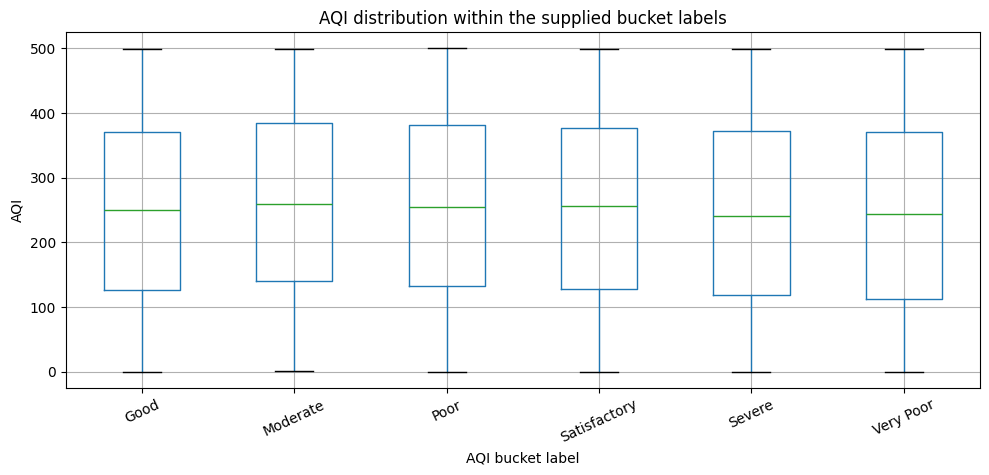

In [29]:
if {"AQI", "AQI_Bucket"}.issubset(df.columns):
    bucket_check = df.groupby("AQI_Bucket", dropna=False)["AQI"].agg(
        records="count", minimum="min", median="median", maximum="max"
    ).sort_values("median")
    display(bucket_check)

    # Pass figsize directly to boxplot. Calling plt.figure() first would open a
    # second, empty figure because pandas creates its own.
    ax = df.boxplot(column="AQI", by="AQI_Bucket", rot=25, figsize=(10, 5))
    ax.set_title("AQI distribution within the supplied bucket labels")
    plt.suptitle("")
    ax.set_xlabel("AQI bucket label")
    ax.set_ylabel("AQI")
    plt.tight_layout()
    plt.show()

### Testing the labels against the published AQI bands

I checked two things more closely:

1. Distribution of values: I used a Kolmogorov-Smirnov test to compare selected numeric columns with a uniform distribution across their observed ranges.
2. AQI categories: I compared the supplied labels with the CPCB AQI bands to see whether the categories match the numeric AQI values.

These checks help identify patterns and possible inconsistencies in the dataset.

In [30]:
from scipy.stats import kstest

print("Kolmogorov-Smirnov test against a uniform distribution over each column's range")
print("(a large p-value means uniformity cannot be rejected; alpha = 0.05)\n")
ks_rows = []
pollutant_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3",
                   "Benzene", "Toluene", "Xylene"]
for col in ["AQI"] + [c for c in pollutant_cols if c in df.columns]:
    values = df[col].dropna()
    scaled = (values - values.min()) / (values.max() - values.min())
    stat, p_value = kstest(scaled, "uniform")
    ks_rows.append({"Column": col, "KS_statistic": stat, "p_value": p_value})
ks_table = pd.DataFrame(ks_rows).set_index("Column").round(4)
display(ks_table)

rejected = ks_table[ks_table["p_value"] < 0.05]
print(f"\nUniformity is rejected at the 5% level for {len(rejected)} of {len(ks_table)} columns:",
      list(rejected.index) if len(rejected) else "none")
print("With 13 independent tests at alpha=0.05, roughly 0.65 false rejections are expected by")
print("chance alone, so a single borderline rejection (NOx, p=0.022) does not overturn the")
print("general pattern; it is flagged rather than smoothed over.")

# Supplied labels vs the published CPCB AQI bands.
cpcb_bands = [0, 50, 100, 200, 300, 400, 500]
cpcb_names = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
band = pd.cut(df["AQI"], bins=cpcb_bands, labels=cpcb_names, include_lowest=True)
crosstab = pd.crosstab(df["AQI_Bucket"], band)
print("\nSupplied AQI_Bucket label (rows) vs CPCB band implied by the numeric AQI (columns):")
display(crosstab)

agreement = (df["AQI_Bucket"].astype(str) == band.astype(str)).mean()
print(f"\nLabel agrees with the CPCB band for {agreement:.1%} of rows.")
print("Random assignment across six labels would give roughly 16.7%.")

Kolmogorov-Smirnov test against a uniform distribution over each column's range
(a large p-value means uniformity cannot be rejected; alpha = 0.05)



,KS_statistic,p_value
Column,,
AQI,0.01,0.74
PM2.5,0.01,0.46
PM10,0.01,0.51
NO,0.01,0.52
NO2,0.01,0.16
NOx,0.01,0.02
NH3,0.01,0.42
CO,0.00,0.97
SO2,0.01,0.22



Uniformity is rejected at the 5% level for 1 of 13 columns: ['NOx']
With 13 independent tests at alpha=0.05, roughly 0.65 false rejections are expected by
chance alone, so a single borderline rejection (NOx, p=0.022) does not overturn the
general pattern; it is flagged rather than smoothed over.

Supplied AQI_Bucket label (rows) vs CPCB band implied by the numeric AQI (columns):


AQI,Good,Satisfactory,Moderate,Poor,Very Poor,Severe
AQI_Bucket,,,,,,
Good,318,302,619,645,615,595
Moderate,260,277,567,617,584,642
Poor,281,284,609,575,621,646
Satisfactory,296,305,612,619,628,638
Severe,342,299,654,612,609,605
Very Poor,315,355,574,577,584,584



Label agrees with the CPCB band for 16.2% of rows.
Random assignment across six labels would give roughly 16.7%.


## Exploratory data analysis

I focused on a few comparisons related to my project questions, including AQI across cities, pollutant distributions, and changes over time. These plots help me understand the patterns present in the supplied dataset.

,count,mean,median,std,min,max
City,,,,,,
Mumbai,3653,253.32,254.40,145.38,0.00,500.00
Delhi,3653,251.50,257.20,143.67,0.20,499.90
Kolkata,3653,250.64,249.50,144.29,0.10,499.90
Chennai,3653,250.34,248.60,144.90,0.30,499.80
Bangalore,3653,249.77,247.80,144.34,0.10,499.90


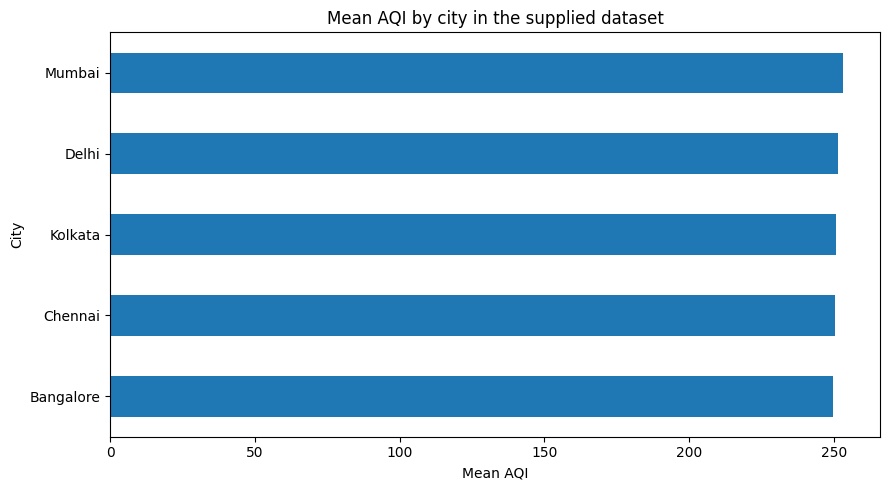

In [31]:
if {"City", "AQI"}.issubset(df.columns):
    city_aqi = df.groupby("City")["AQI"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False)
    display(city_aqi)

    plt.figure(figsize=(9, 5))
    city_aqi["mean"].sort_values().plot(kind="barh")
    plt.title("Mean AQI by city in the supplied dataset")
    plt.xlabel("Mean AQI")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()

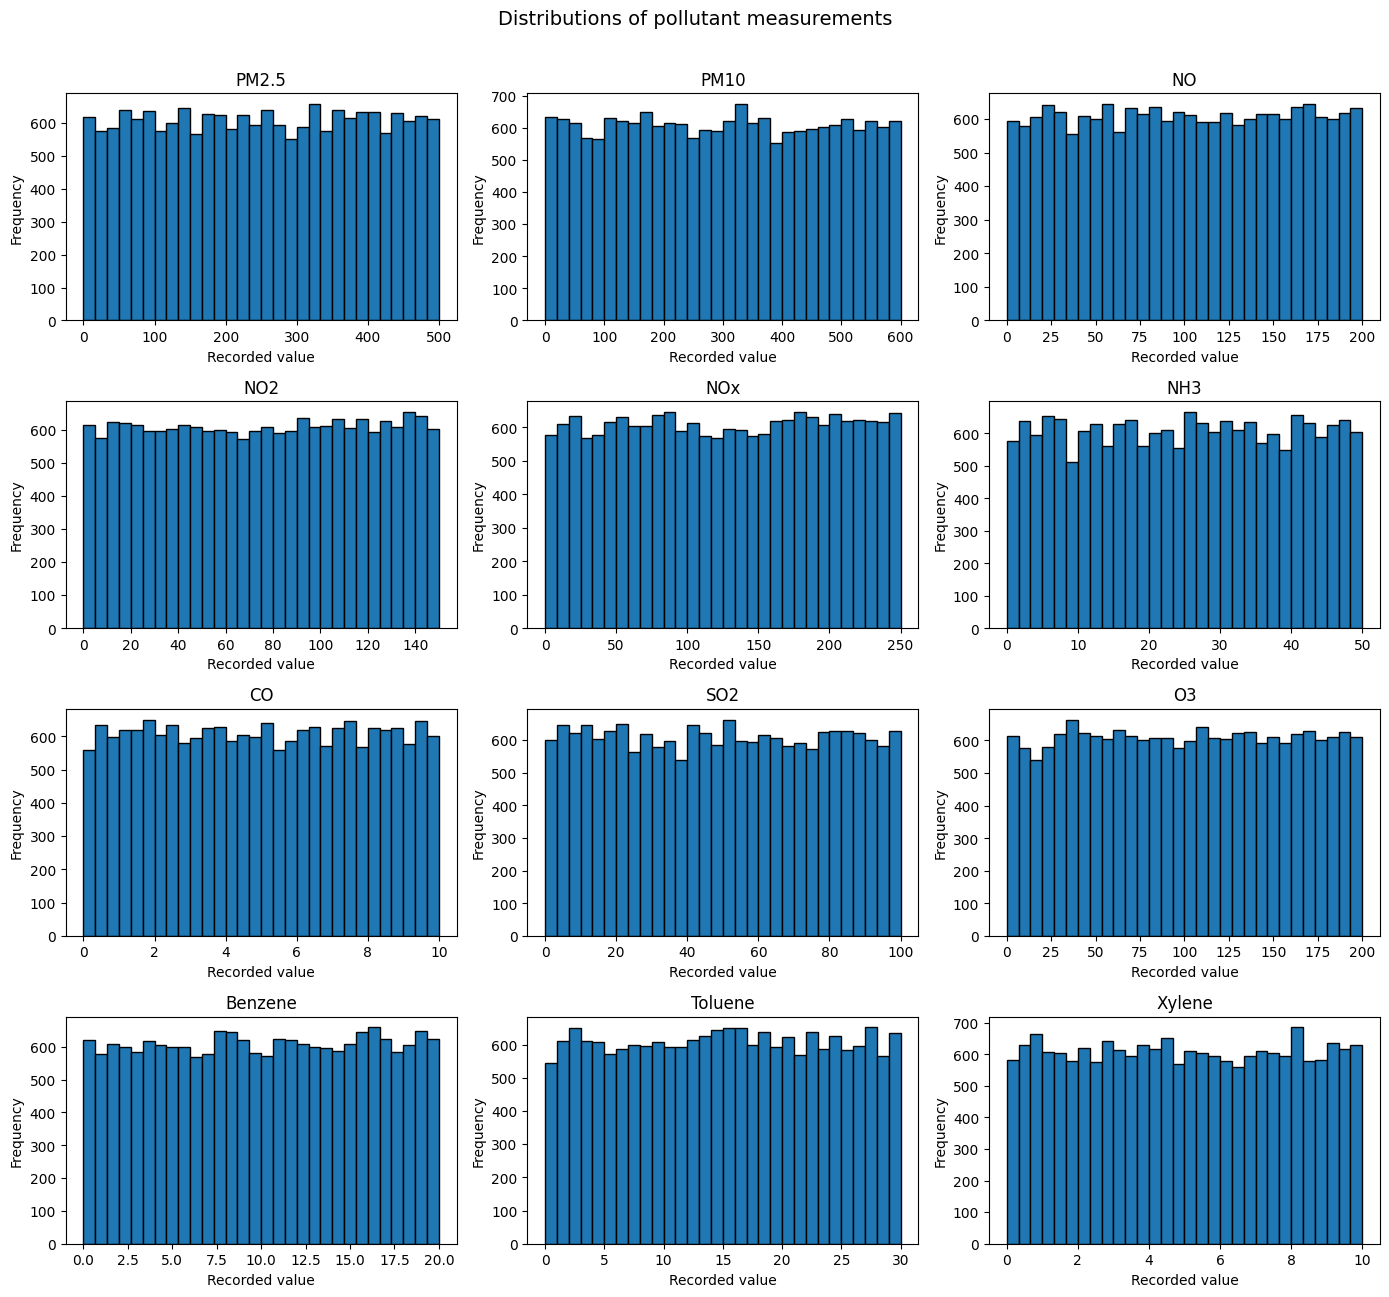

In [32]:
pollutants = [c for c in ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"] if c in df.columns]

if pollutants:
    # One figure with small multiples makes the scales and shapes easier to compare.
    ncols = 3
    nrows = int(np.ceil(len(pollutants) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, pollutants):
        ax.hist(df[col].dropna(), bins=30, edgecolor="black")
        ax.set_title(col)
        ax.set_xlabel("Recorded value")
        ax.set_ylabel("Frequency")
    for ax in axes[len(pollutants):]:
        ax.set_visible(False)
    fig.suptitle("Distributions of pollutant measurements", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

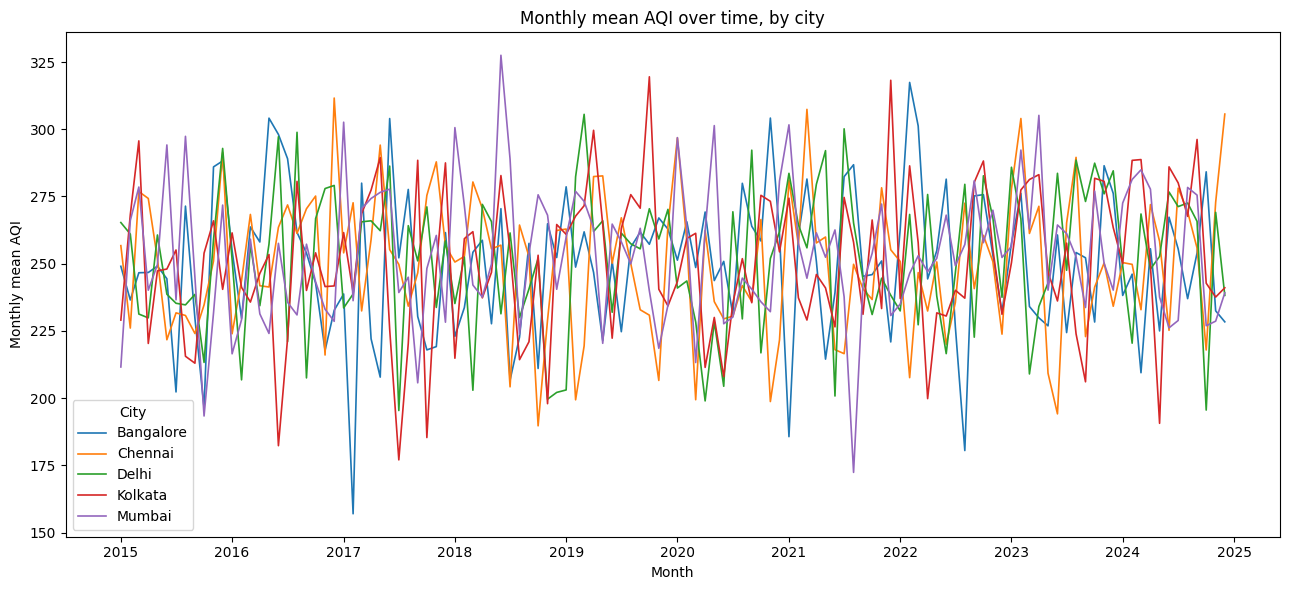

In [33]:
if {"Datetime", "AQI"}.issubset(df.columns):
    # Daily observations are summarized by month to make the long timeline readable.
    monthly = df.set_index("Datetime").groupby("City")["AQI"].resample("MS").mean().reset_index()
    plt.figure(figsize=(13, 6))
    for city, part in monthly.groupby("City"):
        plt.plot(part["Datetime"], part["AQI"], label=city, linewidth=1.2)
    plt.title("Monthly mean AQI over time, by city")
    plt.xlabel("Month")
    plt.ylabel("Monthly mean AQI")
    plt.legend(title="City")
    plt.tight_layout()
    plt.show()

City,Bangalore,Chennai,Delhi,Kolkata,Mumbai
Month,,,,,
1,243.97,260.51,248.06,248.29,265.36
2,247.12,247.15,250.19,262.46,262.06
3,258.11,252.49,245.14,265.16,258.18
4,248.21,262.37,250.04,247.06,260.03
5,237.49,253.95,256.56,244.17,250.39
6,266.73,233.44,246.74,234.81,267.05
7,239.46,245.04,250.93,246.04,246.56
8,252.78,256.36,262.03,244.50,245.20
9,252.39,242.24,249.11,248.22,249.78


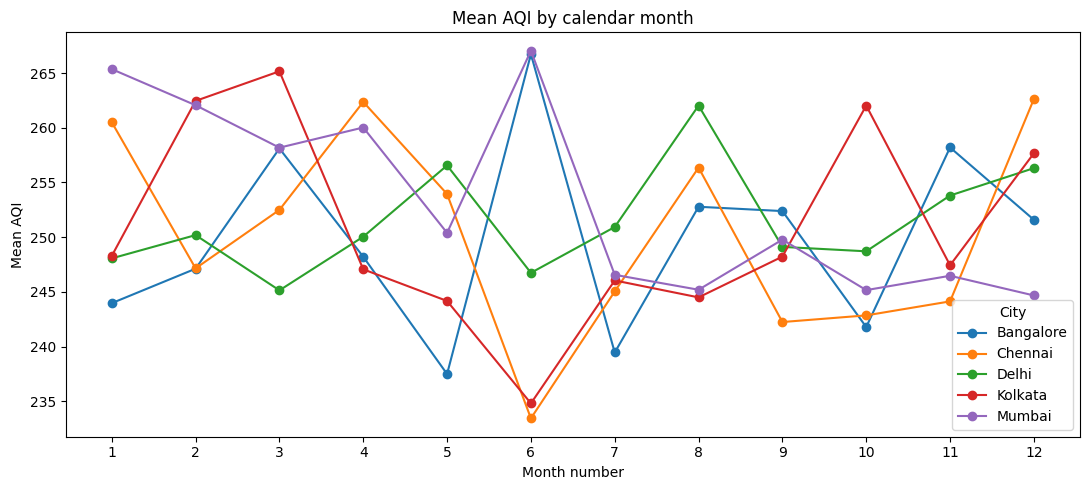

In [34]:
# Month-of-year view: useful for spotting recurring seasonal patterns in this dataset.
if {"Datetime", "AQI"}.issubset(df.columns):
    temp = df.copy()
    temp["Month"] = temp["Datetime"].dt.month
    month_city = temp.groupby(["Month", "City"])["AQI"].mean().unstack("City")
    display(month_city)
    month_city.plot(figsize=(11, 5), marker="o")
    plt.title("Mean AQI by calendar month")
    plt.xlabel("Month number")
    plt.ylabel("Mean AQI")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

## Relationships between variables

Correlation is a measure of association, not evidence that one variable causes another.

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
PM2.5,1.00,-0.02,-0.00,0.01,0.00,0.01,0.01,0.01,0.01,-0.01,-0.00,-0.00,0.00
PM10,-0.02,1.00,0.00,0.00,-0.00,0.00,-0.01,0.01,-0.01,0.01,-0.00,0.00,0.00
NO,-0.00,0.00,1.00,-0.00,0.00,0.00,-0.01,-0.00,-0.01,0.00,-0.01,0.01,0.00
NO2,0.01,0.00,-0.00,1.00,0.00,-0.01,0.01,-0.01,0.00,-0.00,-0.00,0.00,0.01
NOx,0.00,-0.00,0.00,0.00,1.00,-0.00,-0.00,-0.02,0.01,-0.01,-0.00,-0.01,-0.00
NH3,0.01,0.00,0.00,-0.01,-0.00,1.00,-0.00,0.00,-0.00,-0.01,0.01,0.00,0.01
CO,0.01,-0.01,-0.01,0.01,-0.00,-0.00,1.00,-0.00,-0.00,0.01,-0.00,0.01,0.01
SO2,0.01,0.01,-0.00,-0.01,-0.02,0.00,-0.00,1.00,0.00,-0.01,0.00,0.00,0.00
O3,0.01,-0.01,-0.01,0.00,0.01,-0.00,-0.00,0.00,1.00,-0.01,0.00,-0.00,0.00
Benzene,-0.01,0.01,0.00,-0.00,-0.01,-0.01,0.01,-0.01,-0.01,1.00,-0.00,-0.01,-0.00


,correlation_with_AQI
NOx,-0.00
Benzene,-0.00
O3,0.00
PM2.5,0.00
PM10,0.00
NO,0.00
SO2,0.00
CO,0.01
NH3,0.01
Toluene,0.01


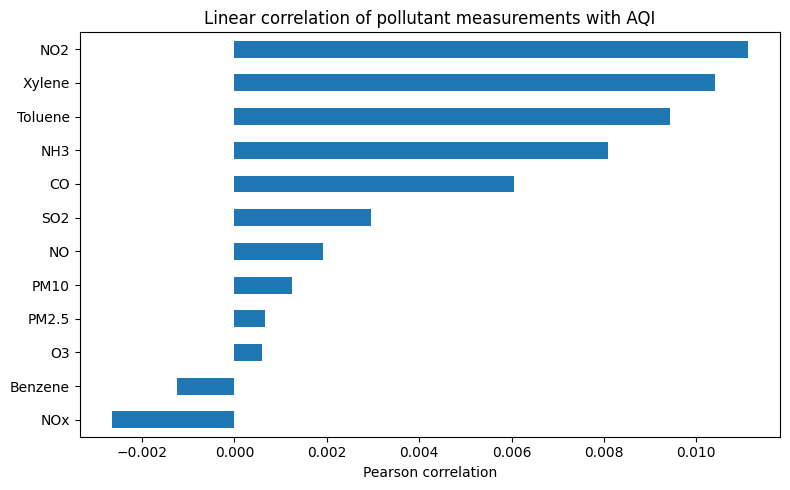

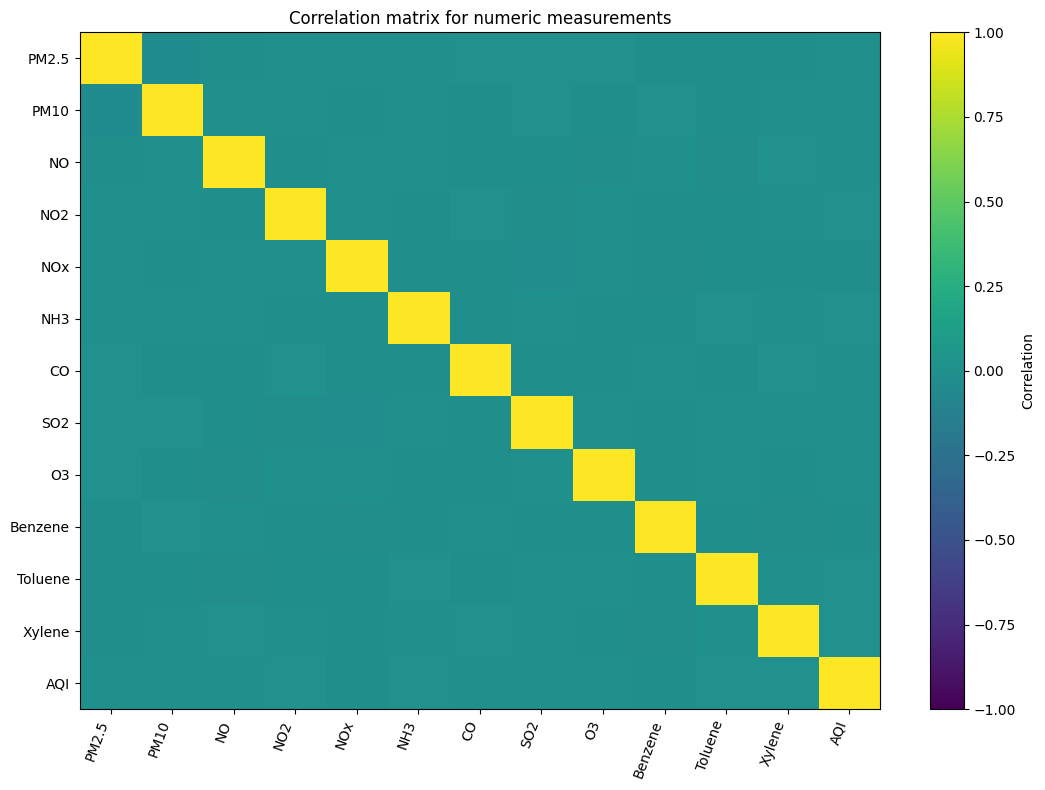

In [35]:
corr_cols = [c for c in pollutants + (["AQI"] if "AQI" in df.columns else []) if c in df.columns]
correlation = df[corr_cols].corr(numeric_only=True)
display(correlation)

if "AQI" in correlation.columns:
    aqi_corr = correlation["AQI"].drop("AQI").sort_values()
    display(aqi_corr.rename("correlation_with_AQI").to_frame())
    plt.figure(figsize=(8, 5))
    aqi_corr.plot(kind="barh")
    plt.title("Linear correlation of pollutant measurements with AQI")
    plt.xlabel("Pearson correlation")
    plt.tight_layout()
    plt.show()

# Correlation matrix plot using matplotlib only.
fig, ax = plt.subplots(figsize=(11, 8))
image = ax.imshow(correlation, aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=70, ha="right")
ax.set_yticks(range(len(correlation.index)), correlation.index)
ax.set_title("Correlation matrix for numeric measurements")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

## Prepare data for regression



In [36]:
required = ["AQI", "Datetime", "City"]
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f"Required columns missing: {missing_required}")

feature_cols = pollutants + ["City"]
model_data = df[required + pollutants].copy()
model_data = model_data.dropna(subset=["AQI", "Datetime", "City"]).sort_values("Datetime")

unique_dates = np.array(sorted(model_data["Datetime"].unique()))
split_index = int(len(unique_dates) * 0.8)
split_index = min(max(split_index, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[split_index])
train_df = model_data[model_data["Datetime"] < cutoff_date].copy()
test_df = model_data[model_data["Datetime"] >= cutoff_date].copy()

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df["AQI"]
y_test = test_df["AQI"]

print("Training date range:", train_df["Datetime"].min(), "to", train_df["Datetime"].max())
print("Testing date range:", test_df["Datetime"].min(), "to", test_df["Datetime"].max())
print("Training rows:", len(train_df), "| Testing rows:", len(test_df))
print("Cutoff date:", cutoff_date.date())

Training date range: 2015-01-01 00:00:00 to 2022-12-31 00:00:00
Testing date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
Training rows: 14610 | Testing rows: 3655
Cutoff date: 2023-01-01


## Feature engineering — adding calendar context

I added calendar features such as month and time of year to check whether dates provide any extra information about AQI. I compared these models with the ones using only pollutant measurements and city.

I used the same training and testing dates for a fair comparison. These features show when a record was collected, but they do not prove that the time period caused a change in AQI.

In [37]:
# Create calendar features from the observation date.
# Month and day-of-year are represented cyclically so December/January
# and the end/start of the year are treated as neighbouring periods.
def add_calendar_features(frame):
    out = frame.copy()
    out["month"] = out["Datetime"].dt.month
    # day_of_year is kept as a diagnostic column only. It is NOT passed to any
    # model; the cyclical month encodings below carry the seasonal information.
    out["day_of_year"] = out["Datetime"].dt.dayofyear
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["year"] = out["Datetime"].dt.year
    return out

train_fe = add_calendar_features(train_df)
test_fe = add_calendar_features(test_df)

calendar_features = pollutants + ["City", "month_sin", "month_cos", "year"]
print("Calendar features used as model inputs:", ["month_sin", "month_cos", "year"])
print("Computed but not used as an input:", ["month", "day_of_year"])
display(train_fe[["Datetime", "month_sin", "month_cos", "year"]].head())

Calendar features used as model inputs: ['month_sin', 'month_cos', 'year']
Computed but not used as an input: ['month', 'day_of_year']


,Datetime,month_sin,month_cos,year
0,2015-01-01,0.50,0.87,2015
1,2015-01-01,0.50,0.87,2015
2,2015-01-01,0.50,0.87,2015
3,2015-01-01,0.50,0.87,2015
4,2015-01-01,0.50,0.87,2015


## Statistical checks that support the questions

I used a few statistical checks to understand the data better:

- **Spearman correlation** helps check whether two variables generally increase or decrease together.
- **City-wise summaries** help compare pollutant and AQI values across cities.
- **AQI label checks** help me see whether the supplied categories agree with the numeric AQI values.

These results describe patterns in the data and do not prove cause and effect.

In [38]:
from scipy.stats import spearmanr

if "AQI" in df.columns:
    stats_summary = df.groupby("City")["AQI"].agg(
        count="count", mean="mean", median="median", std="std",
        q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75),
        minimum="min", maximum="max"
    )
    stats_summary["IQR"] = stats_summary["q3"] - stats_summary["q1"]
    display(stats_summary.round(2))

    # Spearman association with AQI for available pollutant columns.
    spearman_rows = []
    for col in pollutants:
        pair = df[[col, "AQI"]].dropna()
        if len(pair) >= 3 and pair[col].nunique() > 1 and pair["AQI"].nunique() > 1:
            rho, p_value = spearmanr(pair[col], pair["AQI"])
            spearman_rows.append({
                "Pollutant": col, "Spearman_rho": rho,
                "p_value": p_value, "n": len(pair)
            })
    spearman_table = pd.DataFrame(spearman_rows).sort_values(
        "Spearman_rho", key=lambda s: s.abs(), ascending=False
    )
    print("Spearman correlations with AQI (association only):")
    display(spearman_table.round(4))
else:
    print("AQI column not available; statistical comparisons skipped.")

,count,mean,median,std,q1,q3,minimum,maximum,IQR
City,,,,,,,,,
Bangalore,3653,249.77,247.80,144.34,125.50,376.40,0.10,499.90,250.90
Chennai,3653,250.34,248.60,144.90,125.00,375.60,0.30,499.80,250.60
Delhi,3653,251.50,257.20,143.67,125.10,373.30,0.20,499.90,248.20
Kolkata,3653,250.64,249.50,144.29,125.40,376.70,0.10,499.90,251.30
Mumbai,3653,253.32,254.40,145.38,126.50,380.00,0.00,500.00,253.50


Spearman correlations with AQI (association only):


,Pollutant,Spearman_rho,p_value,n
3,NO2,0.01,0.14,18265
11,Xylene,0.01,0.16,18265
10,Toluene,0.01,0.20,18265
5,NH3,0.01,0.28,18265
6,CO,0.01,0.41,18265
7,SO2,0.00,0.69,18265
4,NOx,-0.00,0.73,18265
2,NO,0.00,0.80,18265
9,Benzene,-0.00,0.86,18265
1,PM10,0.00,0.87,18265


## Train and compare regression models

I compared three models:

- **Mean baseline:** predicts the average AQI from the training data for every test record.
- **Linear Regression:** checks whether a simple linear relationship can help predict AQI.
- **Random Forest Regressor:** can learn more complex patterns in the data.

I evaluated the models on the later dates kept for testing. MAE and RMSE measure prediction error, while R² shows how well the model explains variation in AQI. A negative R² means the model performed worse than predicting the test-set average.

In [39]:
# Separate numeric and categorical columns for preprocessing.
numeric_features = pollutants
categorical_features = ["City"]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
        ("city", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    ],
    remainder="drop"
)

models = {
    "Mean baseline": DummyRegressor(strategy="mean"),
    "Linear Regression": Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    "Random Forest": Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(n_estimators=150, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))]),
}

fitted_models = {}
predictions = {}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fitted_models[name] = model
    predictions[name] = pred
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred),
    })

results = pd.DataFrame(rows).set_index("Model").sort_values("MAE")
display(results)

,MAE,RMSE,R2
Model,,,
Mean baseline,125.14,144.02,-0.00
Linear Regression,125.15,144.02,-0.00
Random Forest,126.17,145.44,-0.02


## Evaluate training fit as well as the holdout



In [40]:
fit_rows = []
for name, fitted in fitted_models.items():
    train_pred = fitted.predict(X_train)
    test_pred = predictions[name]
    fit_rows.append({
        "Model": name,
        "Train_MAE": mean_absolute_error(y_train, train_pred),
        "Test_MAE": mean_absolute_error(y_test, test_pred),
        "Train_RMSE": mean_squared_error(y_train, train_pred) ** 0.5,
        "Test_RMSE": mean_squared_error(y_test, test_pred) ** 0.5,
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred)
    })
fit_comparison = pd.DataFrame(fit_rows).set_index("Model")
display(fit_comparison.round(3))

print("Interpretation guide:")
print("- A much lower training error than test error can indicate overfitting.")
print("- High errors on both sets can indicate underfitting or weak predictor signal.")
print("- Similar scores do not prove a model is reliable outside this dataset or time split.")

,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2
Model,,,,,,
Mean baseline,125.15,125.14,144.62,144.02,0.00,-0.00
Linear Regression,125.09,125.15,144.59,144.03,0.00,-0.00
Random Forest,52.45,126.17,61.47,145.44,0.82,-0.02


Interpretation guide:
- A much lower training error than test error can indicate overfitting.
- High errors on both sets can indicate underfitting or weak predictor signal.
- Similar scores do not prove a model is reliable outside this dataset or time split.


## Compare the calendar-enhanced feature set

I compared the models with and without calendar features using the same training and testing dates. The preprocessing steps were fitted using the training data.

This helps me check whether adding date information improves AQI prediction in this dataset.

In [41]:
numeric_features_fe = pollutants + ["month_sin", "month_cos", "year"]
preprocessor_fe = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric_features_fe),
        ("city", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), ["City"])
    ],
    remainder="drop"
)

models_fe = {
    "Linear Regression + calendar": Pipeline([
        ("prep", preprocessor_fe), ("model", LinearRegression())
    ]),
    "Random Forest + calendar": Pipeline([
        ("prep", preprocessor_fe),
        ("model", RandomForestRegressor(
            n_estimators=200, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
}

calendar_rows = []
calendar_fitted = {}
calendar_predictions = {}
for name, model in models_fe.items():
    model.fit(train_fe[calendar_features], y_train)
    pred = model.predict(test_fe[calendar_features])
    calendar_fitted[name] = model
    calendar_predictions[name] = pred
    calendar_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })

calendar_results = pd.DataFrame(calendar_rows).set_index("Model")
print("Calendar-enhanced models on the same later-date holdout:")
display(calendar_results.round(3))

combined_results = pd.concat([
    results[["MAE", "RMSE", "R2"]],
    calendar_results
])
print("Full comparison:")
display(combined_results.round(3))

Calendar-enhanced models on the same later-date holdout:


,MAE,RMSE,R2
Model,,,
Linear Regression + calendar,125.08,143.97,-0.00
Random Forest + calendar,125.96,145.37,-0.02


Full comparison:


,MAE,RMSE,R2
Model,,,
Mean baseline,125.14,144.02,-0.00
Linear Regression,125.15,144.03,-0.00
Random Forest,126.17,145.44,-0.02
Linear Regression + calendar,125.08,143.97,-0.00
Random Forest + calendar,125.96,145.37,-0.02


### Training vs Test Performance

Earlier, I compared training and test performance for the original models. Here, I include all five model versions so I can also check whether adding calendar features changes their performance.

In [42]:
all_fitted = {**fitted_models, **calendar_fitted}

full_fit_rows = []
for name, fitted in all_fitted.items():
    if name in calendar_fitted:
        tr_X, te_X = train_fe[calendar_features], test_fe[calendar_features]
    else:
        tr_X, te_X = X_train, X_test
    train_pred = fitted.predict(tr_X)
    test_pred = fitted.predict(te_X)
    full_fit_rows.append({
        "Model": name,
        "Train_MAE": mean_absolute_error(y_train, train_pred),
        "Test_MAE": mean_absolute_error(y_test, test_pred),
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred),
    })

full_fit = pd.DataFrame(full_fit_rows).set_index("Model")
full_fit["R2_gap"] = full_fit["Train_R2"] - full_fit["Test_R2"]
display(full_fit.round(3))

print("A large positive R2_gap indicates the model fitted training-set noise that did not")
print("carry over to the later test period.")

,Train_MAE,Test_MAE,Train_R2,Test_R2,R2_gap
Model,,,,,
Mean baseline,125.15,125.14,0.00,-0.00,0.00
Linear Regression,125.09,125.15,0.00,-0.00,0.00
Random Forest,52.45,126.17,0.82,-0.02,0.84
Linear Regression + calendar,125.05,125.08,0.00,-0.00,0.00
Random Forest + calendar,52.13,125.96,0.82,-0.02,0.84


A large positive R2_gap indicates the model fitted training-set noise that did not
carry over to the later test period.


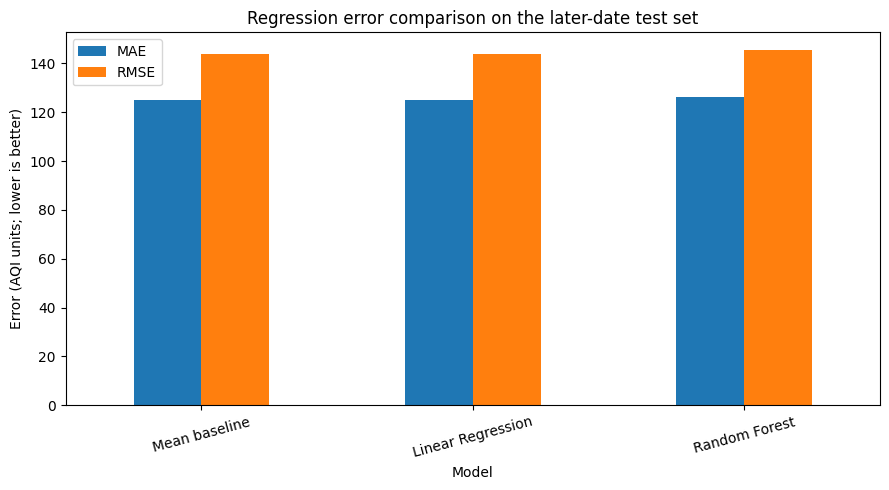

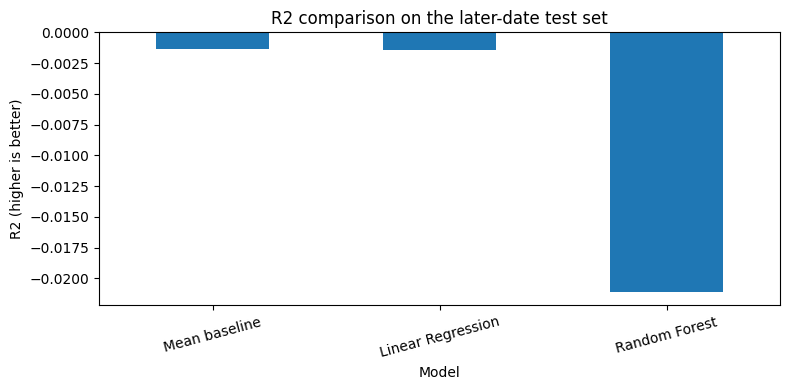

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))
results[["MAE", "RMSE"]].plot(kind="bar", ax=ax)
ax.set_title("Regression error comparison on the later-date test set")
ax.set_ylabel("Error (AQI units; lower is better)")
ax.set_xlabel("Model")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
results["R2"].plot(kind="bar", ax=ax)
ax.set_title("R2 comparison on the later-date test set")
ax.set_ylabel("R2 (higher is better)")
ax.set_xlabel("Model")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Error analysis

A single model score may not show the whole picture. I looked at the errors of the model with the lowest test MAE and compared them across cities and AQI ranges. This helps me understand where the predictions were less accurate.

Lowest-MAE model: Mean baseline


,City,Datetime,AQI,Predicted_AQI,Error,Absolute_Error
14614,Bangalore,2023-01-01,241.20,250.05,8.85,8.85
14613,Kolkata,2023-01-01,435.40,250.05,-185.35,185.35
14612,Chennai,2023-01-01,146.20,250.05,103.85,103.85
14610,Delhi,2023-01-01,346.50,250.05,-96.45,96.45
14611,Mumbai,2023-01-01,371.60,250.05,-121.55,121.55



Test error by city - Mean baseline


,records,MAE,Mean_Error,RMSE
City,,,,
Mumbai,731,126.58,-7.81,144.40
Chennai,731,126.17,-4.41,145.12
Kolkata,731,126.02,-8.40,145.38
Bangalore,731,123.52,2.76,142.61
Delhi,731,123.40,-8.56,142.56



Test error by city - Random Forest


,records,MAE,Mean_Error,RMSE
City,,,,
Chennai,731,128.01,-3.94,147.16
Kolkata,731,127.33,-9.44,147.26
Mumbai,731,126.99,-6.27,144.85
Bangalore,731,124.83,3.44,144.44
Delhi,731,123.68,-9.47,143.42


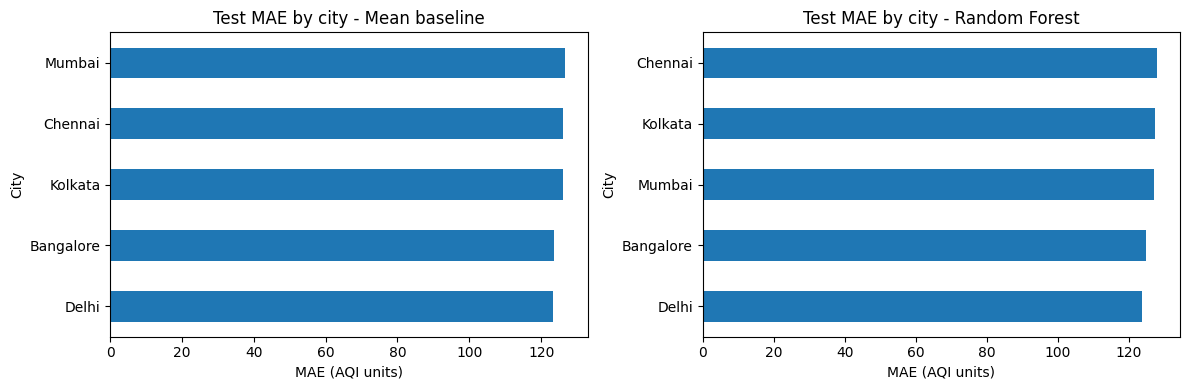

In [44]:
def build_error_frame(pred):
    """Attach predictions and errors to the test rows for one model."""
    frame = test_df[["City", "Datetime", "AQI"]].copy()
    frame["Predicted_AQI"] = pred
    frame["Error"] = frame["Predicted_AQI"] - frame["AQI"]
    frame["Absolute_Error"] = frame["Error"].abs()
    return frame

best_model_name = results["MAE"].idxmin()
print("Lowest-MAE model:", best_model_name)

# The lowest-MAE model turns out to be the trivial baseline, so its error pattern is flat
# by construction. Random Forest is analysed alongside it: comparing the two shows what the
# overfitting in the table above actually looks like at prediction time.
models_to_inspect = [best_model_name]
if "Random Forest" not in models_to_inspect:
    models_to_inspect.append("Random Forest")

error_frames = {name: build_error_frame(predictions[name]) for name in models_to_inspect}
error_df = error_frames[best_model_name]   # kept for continuity with later cells
display(error_frames[best_model_name].head())

for name, frame in error_frames.items():
    city_errors = frame.groupby("City").agg(
        records=("AQI", "size"),
        MAE=("Absolute_Error", "mean"),
        Mean_Error=("Error", "mean"),
        RMSE=("Error", lambda x: np.sqrt(np.mean(np.square(x))))
    ).sort_values("MAE", ascending=False)
    print(f"\nTest error by city - {name}")
    display(city_errors.round(2))

fig, axes = plt.subplots(1, len(error_frames), figsize=(6 * len(error_frames), 4), squeeze=False)
for ax, (name, frame) in zip(axes[0], error_frames.items()):
    frame.groupby("City")["Absolute_Error"].mean().sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"Test MAE by city - {name}")
    ax.set_xlabel("MAE (AQI units)")
    ax.set_ylabel("City")
plt.tight_layout()
plt.show()

Error by observed AQI quartile - Mean baseline


,records,MAE,Mean_Error
AQI_range,,,
"(0.099, 128.6]",916,182.24,182.24
"(128.6, 258.6]",913,57.34,56.78
"(258.6, 379.9]",913,70.45,-70.45
"(379.9, 499.9]",913,190.33,-190.33


Error by observed AQI quartile - Random Forest


,records,MAE,Mean_Error
AQI_range,,,
"(0.099, 128.6]",916,182.11,182.11
"(128.6, 258.6]",913,60.47,58.07
"(258.6, 379.9]",913,71.50,-70.94
"(379.9, 499.9]",913,190.40,-190.40


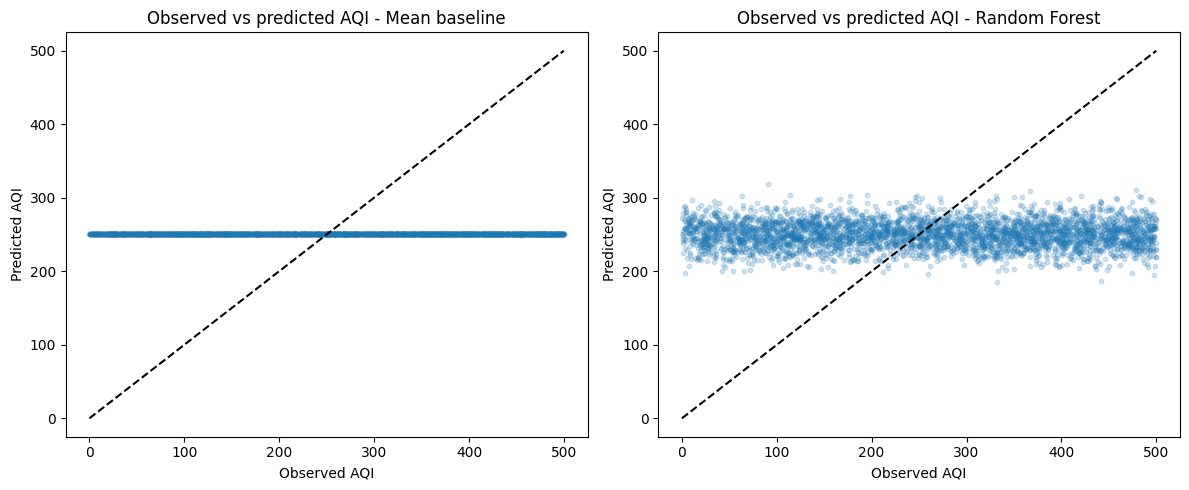

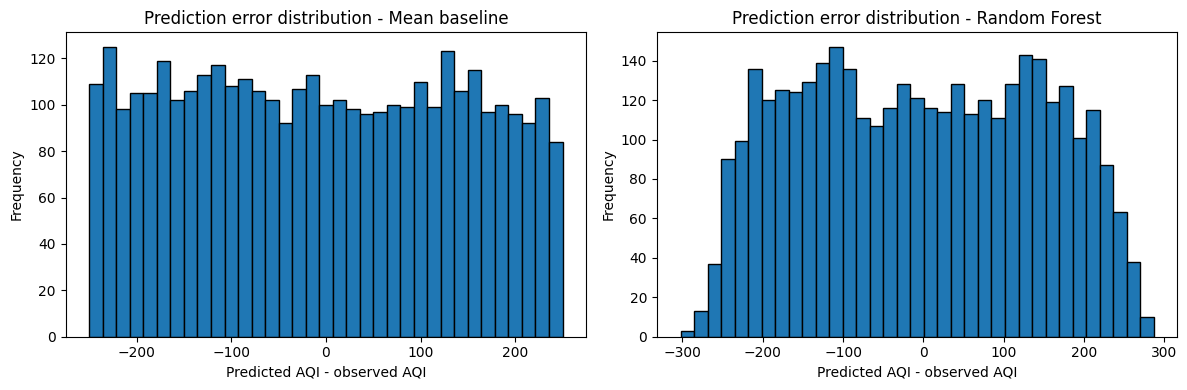

In [45]:
# Bin AQI into quantiles of the test observations to compare errors across the target range.
for name, frame in error_frames.items():
    try:
        frame["AQI_range"] = pd.qcut(frame["AQI"], q=4, duplicates="drop")
        range_errors = frame.groupby("AQI_range", observed=False).agg(
            records=("AQI", "size"),
            MAE=("Absolute_Error", "mean"),
            Mean_Error=("Error", "mean")
        )
        print(f"Error by observed AQI quartile - {name}")
        display(range_errors.round(2))
    except ValueError as exc:
        print("Could not form AQI quantile groups:", exc)

fig, axes = plt.subplots(1, len(error_frames), figsize=(6 * len(error_frames), 5), squeeze=False)
for ax, (name, frame) in zip(axes[0], error_frames.items()):
    ax.scatter(frame["AQI"], frame["Predicted_AQI"], alpha=0.2, s=10)
    low = min(frame["AQI"].min(), frame["Predicted_AQI"].min())
    high = max(frame["AQI"].max(), frame["Predicted_AQI"].max())
    ax.plot([low, high], [low, high], linestyle="--", color="black")
    ax.set_title(f"Observed vs predicted AQI - {name}")
    ax.set_xlabel("Observed AQI")
    ax.set_ylabel("Predicted AQI")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(error_frames), figsize=(6 * len(error_frames), 4), squeeze=False)
for ax, (name, frame) in zip(axes[0], error_frames.items()):
    ax.hist(frame["Error"], bins=35, edgecolor="black")
    ax.set_title(f"Prediction error distribution - {name}")
    ax.set_xlabel("Predicted AQI - observed AQI")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [46]:
print(f"The dataset contains {len(df):,} rows and {df.shape[1]} columns.")
print(f"It covers {df['City'].nunique()} cities and dates from {df['Datetime'].min().date()} to {df['Datetime'].max().date()}.")
print(f"There are {int(df.isna().sum().sum()):,} missing cells after parsing and {int(df.duplicated().sum()):,} exact duplicate rows.")

if "AQI" in df.columns:
    print(f"The overall mean AQI recorded in the file is {df['AQI'].mean():.2f}; the median is {df['AQI'].median():.2f}.")
if "AQI_Bucket" in df.columns and "AQI" in df.columns:
    print("AQI bucket summary (minimum to maximum AQI in each supplied label):")
    display(df.groupby("AQI_Bucket")["AQI"].agg(["min", "median", "max", "count"]))

print("\nModel comparison on the later-date test period:")
display(results)
print(f"Lowest MAE in this comparison: {best_model_name} (MAE={results.loc[best_model_name, 'MAE']:.2f}, RMSE={results.loc[best_model_name, 'RMSE']:.2f}, R²={results.loc[best_model_name, 'R2']:.3f}).")
print("These scores apply to this split and this supplied dataset; they should not be interpreted as a guarantee of performance on new cities, future years, or verified monitoring data.")

The dataset contains 18,265 rows and 16 columns.
It covers 5 cities and dates from 2015-01-01 to 2024-12-31.
There are 0 missing cells after parsing and 0 exact duplicate rows.
The overall mean AQI recorded in the file is 251.11; the median is 251.20.
AQI bucket summary (minimum to maximum AQI in each supplied label):


,min,median,max,count
AQI_Bucket,,,,
Good,0.10,249.90,499.90,3094
Moderate,0.80,260.10,499.90,2947
Poor,0.00,255.00,500.00,3016
Satisfactory,0.30,257.05,499.90,3098
Severe,0.30,241.20,499.80,3121
Very Poor,0.20,243.90,499.90,2989



Model comparison on the later-date test period:


,MAE,RMSE,R2
Model,,,
Mean baseline,125.14,144.02,-0.00
Linear Regression,125.15,144.02,-0.00
Random Forest,126.17,145.44,-0.02


Lowest MAE in this comparison: Mean baseline (MAE=125.14, RMSE=144.02, R²=-0.001).
These scores apply to this split and this supplied dataset; they should not be interpreted as a guarantee of performance on new cities, future years, or verified monitoring data.


### Discussion

The analysis showed that AQI has little variation across cities and months in this dataset. The pollutant values also showed weak correlations with AQI, and the supplied AQI categories did not consistently match the numeric values.

I tested five model versions, but none performed better than the mean baseline. Random Forest showed signs of overfitting, while Linear Regression did not make useful predictions. These findings apply only to this dataset and do not mean that pollutants and AQI are unrelated in real life.

### Limitations

* The data source and AQI calculation method are not clearly documented.
* Some numeric values have unusual distributions, and the supplied AQI categories may be unreliable.
* The models were evaluated using one chronological train-test split.
* Only a few regression approaches were tested.
* The dataset covers five cities, so the findings may not apply elsewhere.

## Conclusion

This project explored air quality across five Indian cities and tested whether pollutant measurements could help predict AQI. Although the dataset had no missing values or duplicate records, the analysis found weak pollutant-AQI relationships and inconsistencies in the AQI categories. None of the models performed better than the mean baseline, so the available pollutant measurements were not useful for reliably estimating AQI in this particular dataset.

